In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
import scipy as scp

In [36]:
titanic = pd.read_csv("./Titanic-Dataset.csv")
titanic = titanic.loc[::, ["Age", "Fare", "Survived"]]
titanic.sample(10)

,Age,Fare,Survived
306,NaN,110.8833,1
889,26.0,30.0000,1
311,18.0,262.3750,1
505,18.0,108.9000,0
729,25.0,7.9250,0
38,18.0,18.0000,0
861,21.0,11.5000,0
884,25.0,7.0500,0
418,30.0,13.0000,0
864,24.0,13.0000,0


In [37]:
titanic.isnull().sum()

Age         177
Fare          0
Survived      0
dtype: int64

In [38]:
titanic.count()

Age         714
Fare        891
Survived    891
dtype: int64

In [39]:
titanic.describe()

,Age,Fare,Survived
count,714.000000,891.000000,891.000000
mean,29.699118,32.204208,0.383838
std,14.526497,49.693429,0.486592
min,0.420000,0.000000,0.000000
25%,20.125000,7.910400,0.000000
50%,28.000000,14.454200,0.000000
75%,38.000000,31.000000,1.000000
max,80.000000,512.329200,1.000000


In [40]:
titanic.fillna(titanic["Age"].mean(), inplace= True)

,Age,Fare,Survived
0,22.000000,7.2500,0
1,38.000000,71.2833,1
2,26.000000,7.9250,1
3,35.000000,53.1000,1
4,35.000000,8.0500,0
...,...,...,...
886,27.000000,13.0000,0
887,19.000000,30.0000,1
888,29.699118,23.4500,0
889,26.000000,30.0000,1


In [41]:
titanic.isnull().sum()

Age         0
Fare        0
Survived    0
dtype: int64

In [42]:
titanic.count()

Age         891
Fare        891
Survived    891
dtype: int64

In [43]:
x = titanic.iloc[::, :2:]
y = titanic.iloc[::, -1]

In [44]:
x_train, x_test, y_train, y_test = skl.model_selection.train_test_split(x, y, test_size= 0.2, random_state= 42)

C:\Users\aliab\AppData\Local\Temp\ipykernel_10580\3347771891.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train["Age"])


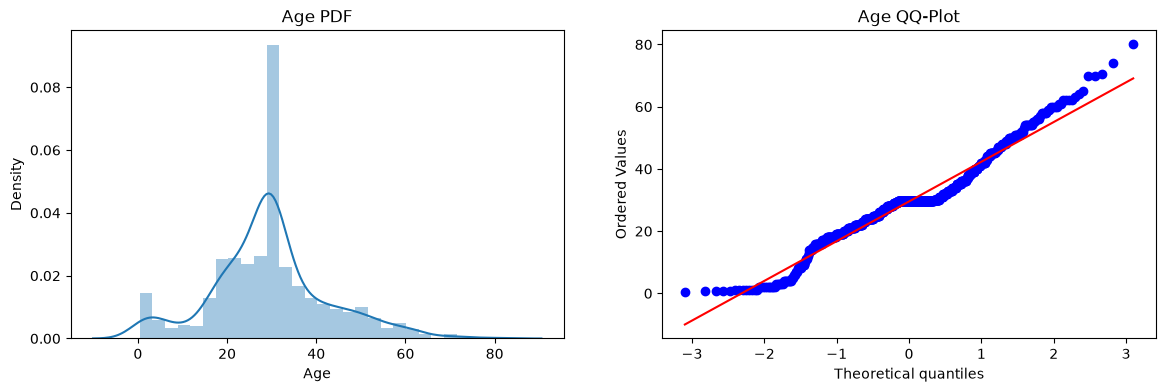

In [45]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.distplot(x_train["Age"])
plt.title("Age PDF")

plt.subplot(122)
scp.stats.probplot(x_train["Age"], dist= "norm", plot= plt)
plt.title("Age QQ-Plot")

plt.show()

C:\Users\aliab\AppData\Local\Temp\ipykernel_10580\3568095103.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train["Fare"])


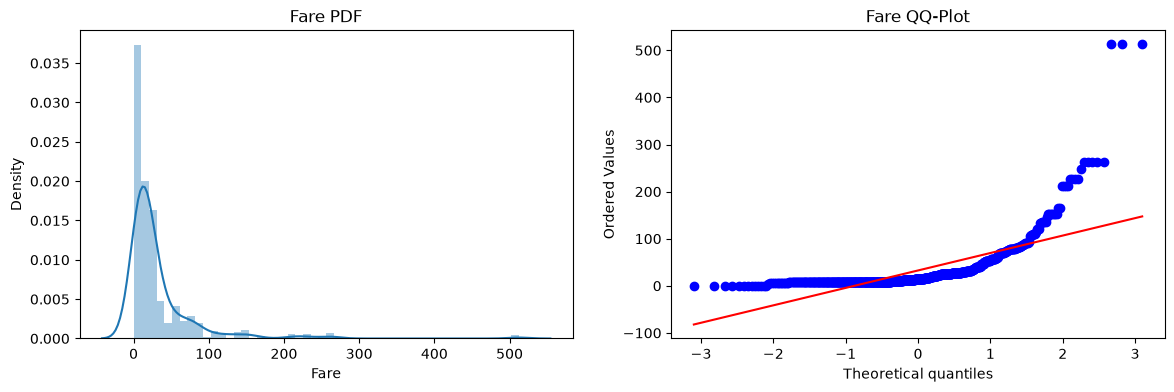

In [46]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.distplot(x_train["Fare"])
plt.title("Fare PDF")

plt.subplot(122)
scp.stats.probplot(x_train["Fare"], dist= "norm", plot= plt)
plt.title("Fare QQ-Plot")

plt.show()

In [56]:
clf1= skl.linear_model.LogisticRegression()
clf2 = skl.tree.DecisionTreeClassifier()

clf1.fit(x_train, y_train)
clf2.fit(x_train, y_train)

y_pred_clf1 = clf1.predict(x_test)
y_pred_clf2 = clf2.predict(x_test)

print(f"Accuracy LR : {skl.metrics.accuracy_score(y_test, y_pred_clf1)}")
print(f"Accuracy DTC : {skl.metrics.accuracy_score(y_test, y_pred_clf2)}")

Accuracy LR : 0.6480446927374302
Accuracy DTC : 0.659217877094972


In [57]:
trf = skl.preprocessing.FunctionTransformer(func= np.log1p)

x_train_trans = trf.fit_transform(x_train)
x_test_trans = trf.transform(x_test)

clf1.fit(x_train_trans, y_train)
clf2.fit(x_train_trans, y_train)

y_pred_clf1 = clf1.predict(x_test)
y_pred_clf2 = clf2.predict(x_test)

print(f"Accuracy LR : {skl.metrics.accuracy_score(y_test, y_pred_clf1)}")
print(f"Accuracy DTC : {skl.metrics.accuracy_score(y_test, y_pred_clf2)}")

Accuracy LR : 0.7374301675977654
Accuracy DTC : 0.5865921787709497


In [59]:
x_trans = trf.fit_transform(x)

clf1= skl.linear_model.LogisticRegression()
clf2 = skl.tree.DecisionTreeClassifier()

print(f"LR : {np.mean(skl.model_selection.cross_val_score(clf1, x_trans, y, scoring= "accuracy", cv= 10))}")
print(f"DTC : {np.mean(skl.model_selection.cross_val_score(clf2, x_trans, y, scoring= "accuracy", cv= 10))}")

LR : 0.678027465667915
DTC : 0.6521348314606742


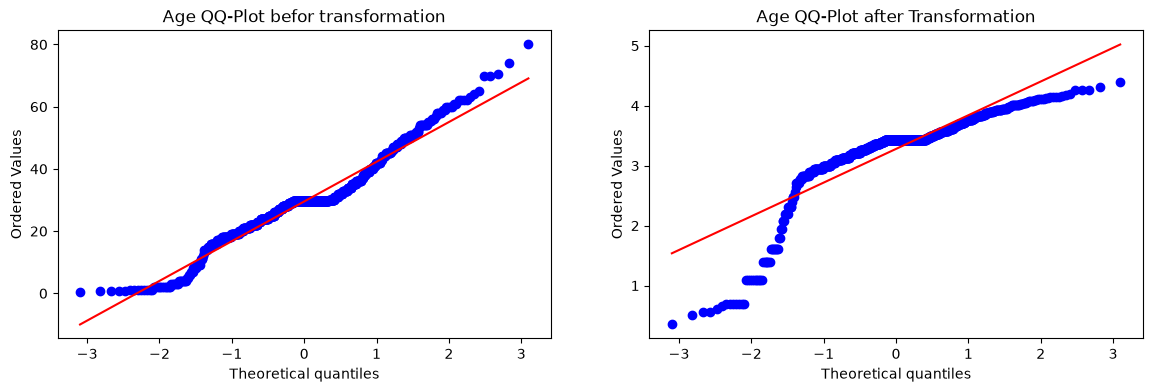

In [60]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
scp.stats.probplot(x_train["Age"], dist= "norm", plot= plt)
plt.title("Age QQ-Plot befor transformation")

plt.subplot(122)
scp.stats.probplot(x_train_trans["Age"], dist= "norm", plot= plt)
plt.title("Age QQ-Plot after Transformation")

plt.show()

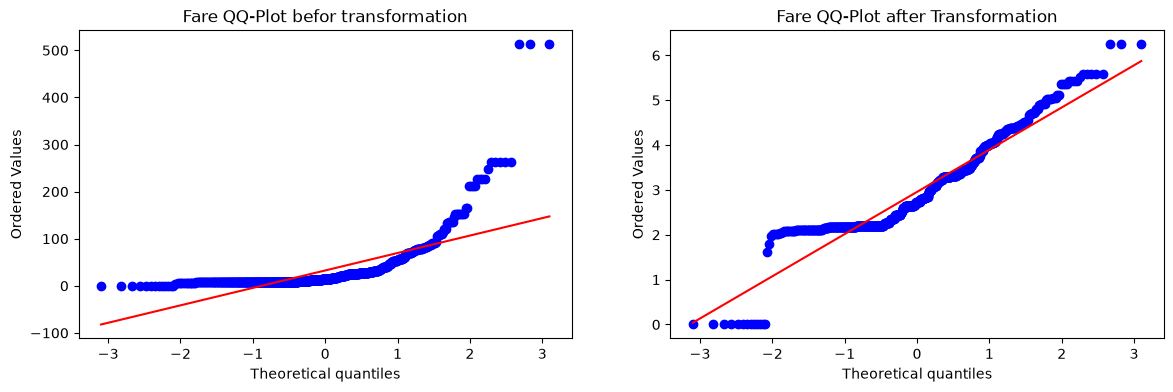

In [61]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
scp.stats.probplot(x_train["Fare"], dist= "norm", plot= plt)
plt.title("Fare QQ-Plot befor transformation")

plt.subplot(122)
scp.stats.probplot(x_train_trans["Fare"], dist= "norm", plot= plt)
plt.title("Fare QQ-Plot after Transformation")

plt.show()

In [62]:
trf2 = skl.compose.ColumnTransformer(transformers= [
    ("log", skl.preprocessing.FunctionTransformer(np.log1p), ["Fare"])
    ], remainder= "passthrough")

x_train_trans_fare = trf2.fit_transform(x_train)
x_test_trans_fare = trf2.transform(x_test)

clf1= skl.linear_model.LogisticRegression()
clf2 = skl.tree.DecisionTreeClassifier()

clf1.fit(x_train_trans_fare, y_train)
clf2.fit(x_train_trans_fare, y_train)

y_pred_fare_clf1 = clf1.predict(x_test)
y_pred_fare_clf2 = clf2.predict(x_test)

print(f"Accuracy LR : {skl.metrics.accuracy_score(y_test, y_pred_fare_clf1)}")
print(f"Accuracy DTC : {skl.metrics.accuracy_score(y_test, y_pred_fare_clf2)}")

Accuracy LR : 0.40782122905027934
Accuracy DTC : 0.6256983240223464


c:\Users\aliab\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\aliab\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


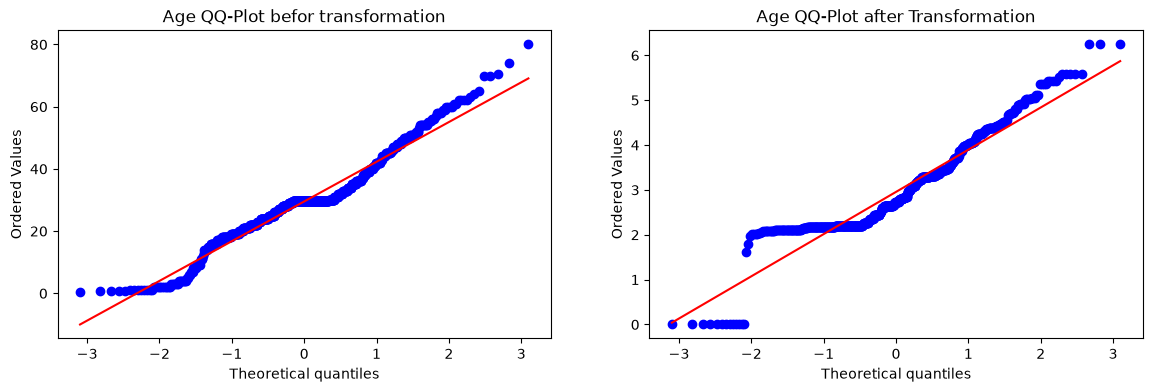

In [65]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
scp.stats.probplot(x_train["Age"], dist= "norm", plot= plt)
plt.title("Age QQ-Plot befor transformation")

plt.subplot(122)
scp.stats.probplot(x_train_trans_fare[::, 0], dist= "norm", plot= plt)
plt.title("Age QQ-Plot after Transformation")

plt.show()